In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
CLEAN_PATH = Path(
    r"D:\clg_project\AI-Financial-Wellness-Coach\data\anomaly\anomaly_transactions_cleaned.csv"
)

df = pd.read_csv(
    CLEAN_PATH,
    parse_dates=["transaction_date"]
)

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (7000, 20)
  transaction_id transaction_date transaction_time                  merchant  \
0      TXN000001       2018-01-01         09:22:10  Credit Card Bill Payment   
1      TXN000002       2018-01-01         12:33:23                     Zepto   
2      TXN000003       2018-01-01         20:17:30        Ace Hardware India   
3      TXN000004       2018-01-01         21:33:19                     Zepto   
4      TXN000005       2018-01-02         08:43:33        House Rent Payment   

                           description    amount currency payment_method  \
0  Auto Debit Credit Card Bill Payment   4361.84      INR     Auto Debit   
1                      UPI/Paytm/Zepto   1226.03      INR            UPI   
2      POS Purchase Ace Hardware India    523.73      INR    Credit Card   
3            UPI/DR/623175732898/Zepto   1290.29      INR            UPI   
4                    NEFT Rent Payment  44800.94      INR           NEFT   

  transaction_type       category   

In [3]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate transaction IDs:",
      df["transaction_id"].duplicated().sum())

Missing values: 0
Duplicate rows: 0
Duplicate transaction IDs: 0


### Analysing transaction amount distribution

In [4]:
print(df["amount"].describe())

count      7000.000000
mean       4989.675896
std       13768.784894
min          30.740000
25%         489.030000
50%        1382.480000
75%        3620.717500
max      240125.840000
Name: amount, dtype: float64


#### Amount Histogram

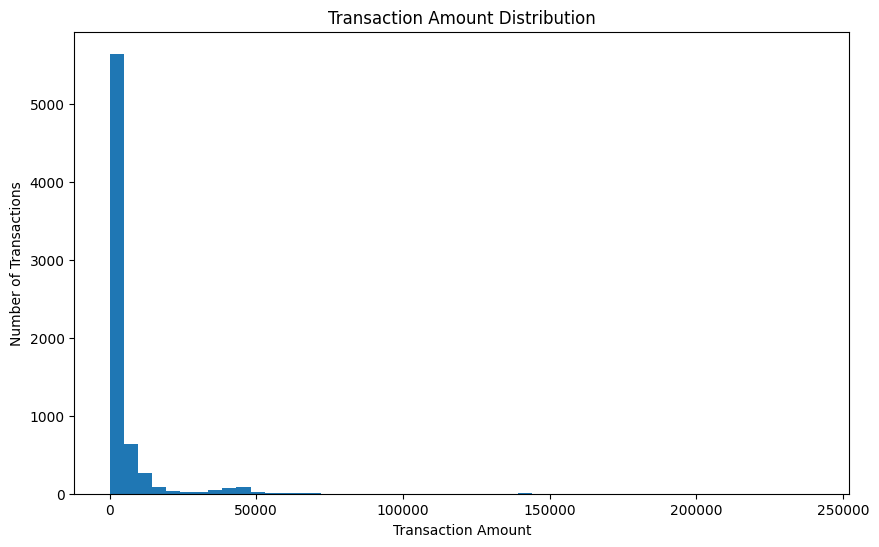

In [5]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["amount"],
    bins=50
)

plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.title("Transaction Amount Distribution")

plt.show()

### Log Scale plot

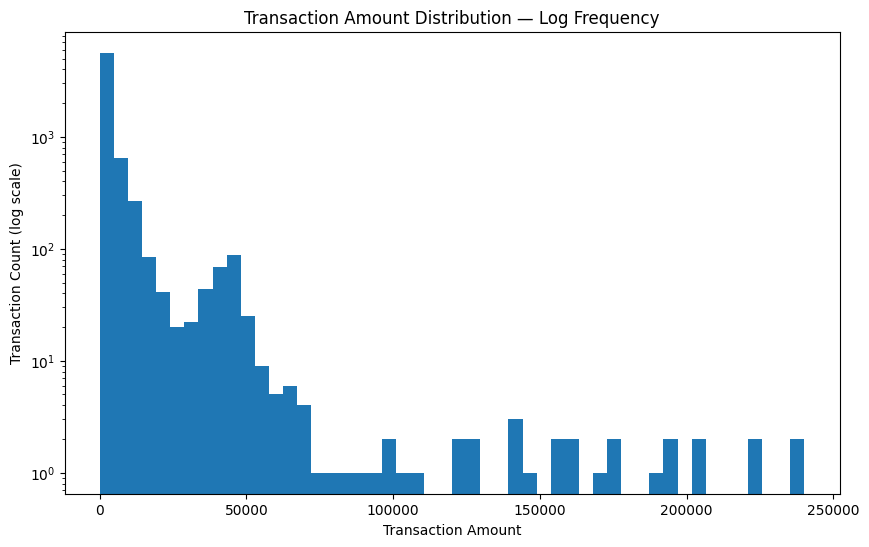

In [6]:
#Because maximum is extremely larger than median, a normal histogram may hide useful details.

plt.figure(figsize=(10, 6))

plt.hist(
    df["amount"],
    bins=50,
    log=True
)

plt.xlabel("Transaction Amount")
plt.ylabel("Transaction Count (log scale)")
plt.title("Transaction Amount Distribution — Log Frequency")

plt.show()

In [7]:
# Amount Percentiles to know: What transaction amount represents the top 1% of transactions?

percentiles = df["amount"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]
)

print(percentiles)

0.500      1382.48000
0.750      3620.71750
0.900      9844.57400
0.950     20933.14200
0.990     49660.98020
0.995     68119.54135
0.999    195609.41084
Name: amount, dtype: float64


### Identifying the largest transactions

In [8]:
top_transactions = df.sort_values(
    "amount",
    ascending=False
).head(20)

print(
    top_transactions[
        [
            "transaction_id",
            "transaction_date",
            "merchant",
            "description",
            "amount",
            "transaction_type",
            "category"
        ]
    ].to_string(index=False)
)

transaction_id transaction_date               merchant        description    amount transaction_type category
     TXN005869       2018-11-05 Employer Salary Credit NEFT Salary Credit 240125.84           Credit   Salary
     TXN006406       2018-07-04 Employer Salary Credit NEFT Salary Credit 238163.14           Credit   Salary
     TXN006660       2019-02-05 Employer Salary Credit NEFT Salary Credit 225266.29           Credit   Salary
     TXN005465       2019-04-03 Employer Salary Credit NEFT Salary Credit 222120.88           Credit   Salary
     TXN005372       2019-06-04 Employer Salary Credit NEFT Salary Credit 203265.19           Credit   Salary
     TXN006332       2019-05-04 Employer Salary Credit NEFT Salary Credit 202071.67           Credit   Salary
     TXN006634       2019-09-01 Employer Salary Credit NEFT Salary Credit 196659.20           Credit   Salary
     TXN006082       2019-09-02 Employer Salary Credit NEFT Salary Credit 195608.36           Credit   Salary
     TXN00

In [9]:
category_stats = (
    df.groupby("category")["amount"]
      .agg(
          transaction_count="count",
          total_amount="sum",
          mean_amount="mean",
          median_amount="median",
          max_amount="max"
      )
      .sort_values("total_amount", ascending=False)
)

print(category_stats.round(2))

               transaction_count  total_amount  mean_amount  median_amount  \
category                                                                     
Salary                       173   11155319.21     64481.61       46862.71   
Bills                       2059    9262536.46      4498.56        2734.38   
Rent                         165    4389360.17     26602.18       30940.78   
Shopping                     550    2349606.50      4272.01        1317.84   
Insurance                    152    2171275.78     14284.71        8584.34   
Fuel                         423    1255800.06      2968.79        3097.93   
Groceries                    912    1186543.15      1301.03         855.48   
Food                        1328    1069805.59       805.58         469.68   
Investment                    36     819101.14     22752.81       20718.72   
Miscellaneous                358     636313.28      1777.41         875.75   
Other                        435     440772.70      1013.27     

In [10]:
category_percentiles = (
    df.groupby("category")["amount"]
      .quantile([0.50, 0.75, 0.90, 0.95, 0.99])
      .unstack()
)

category_percentiles.columns = [
    "P50", "P75", "P90", "P95", "P99"
]

print(category_percentiles.round(2))

                    P50       P75        P90        P95        P99
category                                                          
Bills           2734.38   5714.89   11485.34   14175.79   23248.13
Entertainment    325.25    647.25    1513.05    1738.05    1949.20
Food             469.68   1175.67    2120.76    2529.70    2898.08
Fuel            3097.93   3599.18    4105.05    4505.28    4921.45
Groceries        855.48   1550.26    3203.91    4086.71    4865.86
Insurance       8584.34  13151.23   36626.62   42033.66   47779.99
Investment     20718.72  35926.63   42001.81   44653.32   48004.28
Miscellaneous    875.75   2078.13    4777.14    6947.20    9440.23
Other            783.33   1646.65    2181.24    2413.48    3822.10
Rent           30940.78  42719.73   45740.57   46992.71   47527.22
Salary         46862.71  62172.08  141519.88  181754.96  228877.41
Shopping        1317.84   4795.56   12100.61   14712.81   38946.31
Subscription     303.98    600.04     787.57     814.57     85

In [11]:
# Shopping-- Debit-- ₹49,971.86
#Shopping has:

#Median = ₹1,317.84
#P99    = ₹38,946.31
#Max    = ₹49,971.86

#This indicates a potentially unusual high-end Shopping transaction.

### Analyze amount by category

In [12]:
category_amount = (
    df.groupby("category")["amount"]
      .agg(
          count="count",
          mean="mean",
          median="median",
          std="std",
          min="min",
          max="max"
      )
      .sort_values("median", ascending=False)
)

print(category_amount)

               count          mean     median           std      min  \
category                                                               
Salary           173  64481.613931  46862.710  48518.317270   114.38   
Rent             165  26602.182848  30940.780  15884.557091  7542.54   
Investment        36  22752.809444  20718.725  14544.653869  2485.40   
Insurance        152  14284.709079   8584.340  11526.938330  2237.12   
Fuel             423   2968.794468   3097.930   1004.441320   282.59   
Bills           2059   4498.560690   2734.380   4913.579223   187.00   
Shopping         550   4272.011818   1317.845   7133.348546   288.00   
Miscellaneous    358   1777.411397    875.750   2239.395234    60.00   
Groceries        912   1301.034156    855.480   1126.894396   300.00   
Other            435   1013.270575    783.330    861.383890    30.74   
Food            1328    805.576498    469.685    769.906044   116.00   
Entertainment    167    587.277665    325.250    506.796297   14

### Visualize category spending

<Figure size 1200x700 with 0 Axes>

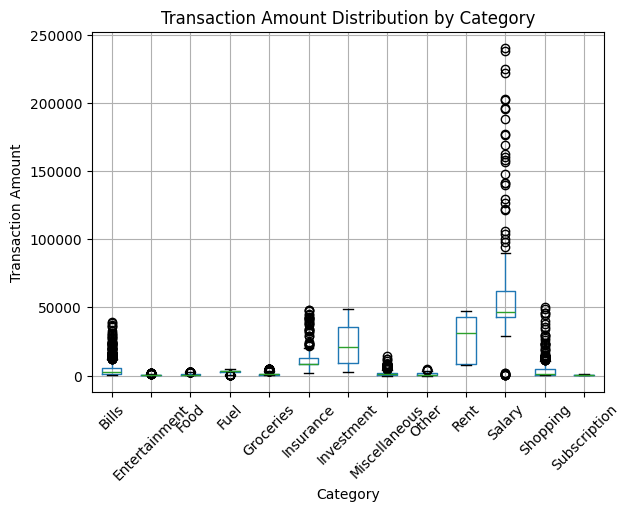

In [13]:
plt.figure(figsize=(12, 7))

df.boxplot(
    column="amount",
    by="category",
    rot=45
)

plt.xlabel("Category")
plt.ylabel("Transaction Amount")
plt.title("Transaction Amount Distribution by Category")

plt.suptitle("")

plt.show()

### Analyze transaction type

In [14]:
print(
    df["transaction_type"].value_counts()
)

transaction_type
Debit     6810
Credit     190
Name: count, dtype: int64


In [15]:
transaction_type_stats = (
    df.groupby("transaction_type")["amount"]
      .agg(
          count="count",
          mean="mean",
          median="median",
          std="std",
          min="min",
          max="max"
      )
)

print(transaction_type_stats)

                  count          mean     median           std     min  \
transaction_type                                                         
Credit              190  59108.281263  45968.555  49394.303506  114.38   
Debit              6810   3479.758859   1327.335   6568.130673   30.74   

                        max  
transaction_type             
Credit            240125.84  
Debit              49971.86  


### Category × Transaction Type

In [16]:
category_type = pd.crosstab(
    df["category"],
    df["transaction_type"]
)

print(category_type)

transaction_type  Credit  Debit
category                       
Bills                  0   2059
Entertainment          0    167
Food                   0   1328
Fuel                   0    423
Groceries              0    912
Insurance              0    152
Investment             0     36
Miscellaneous          0    358
Other                  0    435
Rent                   0    165
Salary               173      0
Shopping              17    533
Subscription           0    242


In [17]:
print(
    pd.crosstab(
        df["category"],
        df["transaction_type"],
        normalize="index"
    ).round(3)
)

transaction_type  Credit  Debit
category                       
Bills              0.000  1.000
Entertainment      0.000  1.000
Food               0.000  1.000
Fuel               0.000  1.000
Groceries          0.000  1.000
Insurance          0.000  1.000
Investment         0.000  1.000
Miscellaneous      0.000  1.000
Other              0.000  1.000
Rent               0.000  1.000
Salary             1.000  0.000
Shopping           0.031  0.969
Subscription       0.000  1.000


### Merchant Frequency

In [18]:
merchant_counts = (
    df["merchant"]
      .value_counts()
)

print("Number of unique merchants:",
      df["merchant"].nunique())

print("\nTop 20 merchants:")
print(merchant_counts.head(20))

Number of unique merchants: 99

Top 20 merchants:
merchant
Credit Card Bill Payment      693
DMart                         178
Airtel                        175
Reliance Fresh                167
House Rent Payment            165
Employer Salary Credit        163
Indian Oil                    162
Municipal Water Department    155
BigBasket                     146
HPCL                          143
Nature's Basket               143
Blinkit                       140
Zepto                         138
Jio                           137
Amazon India                  123
BPCL                          118
Cafe Coffee Day               117
Zomato                        117
Tata Power                    116
Myntra                        115
Name: count, dtype: int64


In [19]:
merchant_amount = (
    df.groupby("merchant")["amount"]
      .agg(
          count="count",
          mean="mean",
          median="median",
          max="max"
      )
      .sort_values("count", ascending=False)
)

print(merchant_amount.head(20).round(2))

                            count      mean    median        max
merchant                                                        
Credit Card Bill Payment      693   3366.57   2662.02   15776.17
DMart                         178   1262.27    868.73    4927.95
Airtel                        175   3541.98   1797.25   15718.85
Reliance Fresh                167   1442.02    922.53    4978.56
House Rent Payment            165  26602.18  30940.78   47664.75
Employer Salary Credit        163  68381.18  47492.08  240125.84
Indian Oil                    162   2900.95   3058.50    4923.29
Municipal Water Department    155   2911.91    918.19   15120.24
BigBasket                     146   1189.00    794.62    4932.56
HPCL                          143   3068.03   3187.85    4972.45
Nature's Basket               143   1363.29    759.82    4966.93
Blinkit                       140   1130.42    819.33    4942.59
Zepto                         138   1407.52   1041.57    4956.19
Jio                      

### Merchant Amount Behavior

In [20]:
merchant_variation = (
    df.groupby("merchant")["amount"]
      .agg(
          count="count",
          mean="mean",
          median="median",
          std="std",
          min="min",
          max="max"
      )
)

merchant_variation["range"] = (
    merchant_variation["max"] -
    merchant_variation["min"]
)

print(
    merchant_variation
    .sort_values("std", ascending=False)
    .head(20)
    .round(2)
)

                        count      mean    median       std       min  \
merchant                                                                
Employer Salary Credit    163  68381.18  47492.08  47271.77  28930.95   
HDFC Mutual Fund            8  21536.51  19952.98  16612.32   2723.11   
House Rent Payment        165  26602.18  30940.78  15884.56   7542.54   
ICICI Prudential MF        12  29341.97  31568.27  14094.10   6045.93   
Mutual Fund SIP            11  20119.64  15056.34  14001.27   3360.14   
Bajaj Allianz              44  15834.35   8825.56  12539.67   5240.12   
ICICI Lombard              39  15284.85   8656.61  12179.98   8026.41   
Income Tax Payment         36  18791.12  15524.22  11812.39   3194.31   
HDFC Ergo                  42  13223.93   8450.88  11307.35   2237.12   
SBI Mutual Fund             5  14677.87  15938.03   9896.88   2485.40   
LIC                        27  11964.82   8427.55   8955.50   5195.11   
Nykaa                      66   5541.14   1673.21  

In [21]:
merchant_reliable = merchant_variation[
    merchant_variation["count"] >= 20
].sort_values(
    "std",
    ascending=False
)

print(
    merchant_reliable.head(20).round(2)
)

                            count      mean    median       std       min  \
merchant                                                                    
Employer Salary Credit        163  68381.18  47492.08  47271.77  28930.95   
House Rent Payment            165  26602.18  30940.78  15884.56   7542.54   
Bajaj Allianz                  44  15834.35   8825.56  12539.67   5240.12   
ICICI Lombard                  39  15284.85   8656.61  12179.98   8026.41   
Income Tax Payment             36  18791.12  15524.22  11812.39   3194.31   
HDFC Ergo                      42  13223.93   8450.88  11307.35   2237.12   
LIC                            27  11964.82   8427.55   8955.50   5195.11   
Nykaa                          66   5541.14   1673.21   8750.88    288.00   
Ajio                           70   5251.04   1693.04   7870.80    288.00   
Meesho                         68   4186.12   1174.36   7647.29    288.00   
Amazon India                  123   4341.33   1458.35   7570.71    288.00   

### Transaction Time / Hour Analysis

In [22]:
# Convert transaction_time to datetime
time_test = pd.to_datetime(
    df["transaction_time"],
    errors="coerce"
)

# Extract hour
df["transaction_hour"] = time_test.dt.hour

print("Invalid transaction times:",
      time_test.isna().sum())

print("\nTransaction count by hour:")
print(
    df["transaction_hour"]
    .value_counts()
    .sort_index()
)

Invalid transaction times: 0

Transaction count by hour:
transaction_hour
0     137
1      97
2      77
3      97
4      74
5      77
6     260
7     276
8     516
9     579
10    520
11    484
12    472
13    430
14    404
15    289
16    308
17    287
18    307
19    327
20    338
21    297
22    217
23    130
Name: count, dtype: int64


C:\Users\admin\AppData\Local\Temp\ipykernel_9080\38791257.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time_test = pd.to_datetime(


In [23]:
hour_analysis = (
    df.groupby("transaction_hour")["amount"]
    .agg(
        transaction_count="count",
        mean_amount="mean",
        median_amount="median",
        max_amount="max"
    )
)

print(hour_analysis.round(2))

                  transaction_count  mean_amount  median_amount  max_amount
transaction_hour                                                           
0                               137      9169.28        1918.47    64085.11
1                                97     14932.92        5240.12    67511.50
2                                77      4080.80        1601.14    39793.23
3                                97      6679.87        2624.75    42645.54
4                                74      5160.70        2849.30    44286.70
5                                77      6302.83        4034.22    45517.82
6                               260      4837.68        2554.82    53993.70
7                               276      5222.64        2136.70    63990.66
8                               516      4086.85        1372.62   157900.42
9                               579      5210.56        1489.25   105918.84
10                              520      4196.48        1526.56   140146.77
11          

In [24]:
print("\nTop 10 highest-value transactions by hour:")

print(
    df[
        [
            "transaction_id",
            "transaction_time",
            "merchant",
            "amount",
            "transaction_type",
            "category"
        ]
    ]
    .sort_values("amount", ascending=False)
    .head(10)
)


Top 10 highest-value transactions by hour:
     transaction_id transaction_time                merchant     amount  \
5966      TXN005869         13:54:23  Employer Salary Credit  240125.84   
5584      TXN006406         19:44:29  Employer Salary Credit  238163.14   
6246      TXN006660         11:04:09  Employer Salary Credit  225266.29   
6442      TXN005465         13:55:52  Employer Salary Credit  222120.88   
6614      TXN005372         21:14:15  Employer Salary Credit  203265.19   
6536      TXN006332         21:10:09  Employer Salary Credit  202071.67   
6902      TXN006634         14:11:16  Employer Salary Credit  196659.20   
6906      TXN006082         17:35:54  Employer Salary Credit  195608.36   
6242      TXN006212         21:37:03  Employer Salary Credit  188574.21   
5181      TXN006073         19:28:37  Employer Salary Credit  177208.79   

     transaction_type category  
5966           Credit   Salary  
5584           Credit   Salary  
6246           Credit   Salary 

### Day-of-Week Analysis.

In [25]:
# Convert transaction_date to datetime
df["transaction_date"] = pd.to_datetime(
    df["transaction_date"],
    errors="coerce"
)

# Extract day of week
df["day_of_week"] = df["transaction_date"].dt.day_name()

print("Invalid dates:", df["transaction_date"].isna().sum())

print("\nTransaction count by day:")
print(
    df["day_of_week"]
    .value_counts()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

Invalid dates: 0

Transaction count by day:
day_of_week
Monday        994
Tuesday      1019
Wednesday    1044
Thursday      955
Friday       1043
Saturday      983
Sunday        962
Name: count, dtype: int64


In [26]:
day_analysis = (
    df.groupby("day_of_week")["amount"]
    .agg(
        transaction_count="count",
        mean_amount="mean",
        median_amount="median",
        max_amount="max"
    )
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

print(day_analysis.round(2))

             transaction_count  mean_amount  median_amount  max_amount
day_of_week                                                           
Monday                     994      4564.94        1319.87   240125.84
Tuesday                   1019      5088.53        1330.86   225266.29
Wednesday                 1044      4432.90        1441.70   238163.14
Thursday                   955      4456.83        1405.55   156886.81
Friday                    1043      6312.54        1476.78   177208.79
Saturday                   983      4836.87        1357.61   202071.67
Sunday                     962      5178.91        1367.19   196659.20


In [27]:
day_type_analysis = pd.crosstab(
    df["day_of_week"],
    df["transaction_type"]
).reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

print(day_type_analysis)

transaction_type  Credit  Debit
day_of_week                    
Monday                22    972
Tuesday               24    995
Wednesday             13   1031
Thursday              23    932
Friday                63    980
Saturday              20    963
Sunday                25    937


### Monthly Spending Analysis

In [28]:
monthly_analysis = (
    df.groupby("month")["amount"]
    .agg(
        transaction_count="count",
        total_amount="sum",
        mean_amount="mean",
        median_amount="median",
        max_amount="max"
    )
)

print(monthly_analysis.round(2))

       transaction_count  total_amount  mean_amount  median_amount  max_amount
month                                                                         
1                    561    3167681.50      5646.49        1550.25   156886.81
2                    596    3114105.90      5225.01        1449.44   225266.29
3                    697    3548501.32      5091.11        1295.71   177208.79
4                    745    3511289.40      4713.14        1292.20   222120.88
5                    651    3118952.03      4791.02        1407.58   202071.67
6                    681    3332015.44      4892.83        1402.24   203265.19
7                    667    3299265.08      4946.42        1365.27   238163.14
8                    626    3234737.43      5167.31        1458.01   176264.99
9                    704    3388752.06      4813.57        1368.86   196659.20
10                   320    1550924.90      4846.64        1448.33    48070.60
11                   343    1761015.68      5134.16 

In [29]:
monthly_type_analysis = (
    df.groupby(["month", "transaction_type"])["amount"]
    .agg(
        transaction_count="count",
        total_amount="sum",
        mean_amount="mean"
    )
)

print(monthly_type_analysis.round(2))

                        transaction_count  total_amount  mean_amount
month transaction_type                                              
1     Credit                           17    1141720.26     67160.02
      Debit                           544    2025961.24      3724.19
2     Credit                           17    1172062.67     68944.86
      Debit                           579    1942043.23      3354.13
3     Credit                           24    1165605.84     48566.91
      Debit                           673    2382895.48      3540.71
4     Credit                           20    1181000.23     59050.01
      Debit                           725    2330289.17      3214.19
5     Credit                           13     831688.14     63976.01
      Debit                           638    2287263.89      3585.05
6     Credit                           19    1072014.64     56421.82
      Debit                           662    2260000.80      3413.90
7     Credit                      

In [30]:
monthly_category = (
    df.groupby(["month", "category"])["amount"]
    .agg(
        transaction_count="count",
        total_amount="sum",
        mean_amount="mean"
    )
)

print(monthly_category.round(2))

                     transaction_count  total_amount  mean_amount
month category                                                   
1     Bills                        176     906577.74      5151.01
      Entertainment                 14       6611.87       472.28
      Food                          91      77696.67       853.81
      Fuel                          38     106101.91      2792.16
      Groceries                     71     103887.59      1463.21
...                                ...           ...          ...
12    Other                         31      27374.91       883.06
      Rent                          11     331926.88     30175.17
      Salary                         9     608001.11     67555.68
      Shopping                      32      76483.97      2390.12
      Subscription                   7       2428.68       346.95

[156 rows x 3 columns]


### Weekend vs Weekday Spending Analysis

In [31]:
#Transaction count and spending

weekend_analysis = (
    df.groupby("weekend")["amount"]
    .agg(
        transaction_count="count",
        total_amount="sum",
        mean_amount="mean",
        median_amount="median",
        max_amount="max"
    )
)

print(weekend_analysis.round(2))

         transaction_count  total_amount  mean_amount  median_amount  \
weekend                                                                
0                     5055   25190973.42      4983.38        1390.20   
1                     1945    9736757.85      5006.05        1363.66   

         max_amount  
weekend              
0         240125.84  
1         202071.67  


In [32]:
# Weekend vs Weekday by transaction type

weekend_type_analysis = (
    df.groupby(["weekend", "transaction_type"])["amount"]
    .agg(
        transaction_count="count",
        total_amount="sum",
        mean_amount="mean",
        median_amount="median"
    )
)

print(weekend_type_analysis.round(2))

                          transaction_count  total_amount  mean_amount  \
weekend transaction_type                                                 
0       Credit                          145    8128972.37     56061.88   
        Debit                          4910   17062001.05      3474.95   
1       Credit                           45    3101601.07     68924.47   
        Debit                          1900    6635156.78      3492.19   

                          median_amount  
weekend transaction_type                 
0       Credit                 45807.43  
        Debit                   1329.98  
1       Credit                 48254.84  
        Debit                   1318.34  


In [33]:
# Weekend vs Weekday by category

weekend_category_analysis = (
    df.groupby(["weekend", "category"])["amount"]
    .agg(
        transaction_count="count",
        total_amount="sum",
        mean_amount="mean"
    )
)

print(weekend_category_analysis.round(2))

                       transaction_count  total_amount  mean_amount
weekend category                                                   
0       Bills                       1481    6697891.69      4522.55
        Entertainment                129      77057.50       597.34
        Food                        1001     818443.52       817.63
        Fuel                         307     920715.71      2999.07
        Groceries                    631     847784.87      1343.56
        Insurance                    111    1555594.37     14014.36
        Investment                    27     665549.67     24649.99
        Miscellaneous                248     420589.60      1695.93
        Other                        306     316828.06      1035.39
        Rent                         110    3036312.62     27602.84
        Salary                       133    8084807.71     60788.03
        Shopping                     397    1681231.41      4234.84
        Subscription                 174      68

### Month-end analysis

In [34]:
month_end_analysis = (
    df.groupby("month_end")["amount"]
    .agg(
        transaction_count="count",
        total_amount="sum",
        mean_amount="mean",
        median_amount="median",
        max_amount="max"
    )
)

print(month_end_analysis.round(2))

           transaction_count  total_amount  mean_amount  median_amount  \
month_end                                                                
0                       6691   33703193.24      5037.09        1377.91   
1                        309    1224538.03      3962.91        1495.74   

           max_amount  
month_end              
0           240125.84  
1            48355.87  


### Salary-week analysis

In [35]:
salary_week_analysis = (
    df.groupby("salary_week")["amount"]
    .agg(
        transaction_count="count",
        total_amount="sum",
        mean_amount="mean",
        median_amount="median",
        max_amount="max"
    )
)

print(salary_week_analysis.round(2))

             transaction_count  total_amount  mean_amount  median_amount  \
salary_week                                                                
0                         4852   23140979.48      4769.37        1311.00   
1                         2148   11786751.79      5487.31        1601.48   

             max_amount  
salary_week              
0             240125.84  
1             196659.20  


### Combine both with transaction type

In [36]:
context_analysis = (
    df.groupby(
        ["salary_week", "month_end", "transaction_type"]
    )["amount"]
    .agg(
        transaction_count="count",
        mean_amount="mean",
        median_amount="median",
        max_amount="max"
    )
)

print(context_analysis.round(2))

                                        transaction_count  mean_amount  \
salary_week month_end transaction_type                                   
0           0         Credit                          132     59310.96   
                      Debit                          4720      3244.05   
1           0         Credit                           54     60725.38   
                      Debit                          1785      4080.14   
            1         Credit                            4     30589.11   
                      Debit                           305      3613.71   

                                        median_amount  max_amount  
salary_week month_end transaction_type                             
0           0         Credit                 46289.88   240125.84  
                      Debit                   1263.41    49971.86  
1           0         Credit                 45935.66   196659.20  
                      Debit                   1501.86    48875.36  

### Transaction Frequency Features

In [37]:
# Merchant frequency
merchant_frequency = (
    df["merchant"]
    .value_counts()
    .rename("transaction_count")
    .reset_index()
)

merchant_frequency.columns = ["merchant", "transaction_count"]

print("Merchant frequency:")
print(merchant_frequency.head(20))


# Category frequency
category_frequency = (
    df["category"]
    .value_counts()
    .rename("transaction_count")
    .reset_index()
)

category_frequency.columns = ["category", "transaction_count"]

print("\nCategory frequency:")
print(category_frequency)


# Payment method frequency
payment_frequency = (
    df["payment_method"]
    .value_counts()
    .rename("transaction_count")
    .reset_index()
)

payment_frequency.columns = ["payment_method", "transaction_count"]

print("\nPayment method frequency:")
print(payment_frequency)

Merchant frequency:
                      merchant  transaction_count
0     Credit Card Bill Payment                693
1                        DMart                178
2                       Airtel                175
3               Reliance Fresh                167
4           House Rent Payment                165
5       Employer Salary Credit                163
6                   Indian Oil                162
7   Municipal Water Department                155
8                    BigBasket                146
9                         HPCL                143
10             Nature's Basket                143
11                     Blinkit                140
12                       Zepto                138
13                         Jio                137
14                Amazon India                123
15                        BPCL                118
16             Cafe Coffee Day                117
17                      Zomato                117
18                  Tata Power

### Merchant + Category Behavioral Features

In [38]:
# Step 4.19: Merchant and Category behavioral features

# -----------------------------
# Merchant-level statistics
# -----------------------------
merchant_stats = (
    df.groupby("merchant")["amount"]
    .agg(
        merchant_transaction_count="count",
        merchant_mean_amount="mean",
        merchant_median_amount="median",
        merchant_std_amount="std"
    )
    .reset_index()
)

df = df.merge(merchant_stats, on="merchant", how="left")


# -----------------------------
# Category-level statistics
# -----------------------------
category_stats_model = (
    df.groupby("category")["amount"]
    .agg(
        category_transaction_count="count",
        category_mean_amount="mean",
        category_median_amount="median",
        category_std_amount="std"
    )
    .reset_index()
)

df = df.merge(category_stats_model, on="category", how="left")


# -----------------------------
# Amount relative to merchant
# -----------------------------
df["amount_vs_merchant_mean"] = (
    df["amount"] / df["merchant_mean_amount"]
)

df["amount_vs_merchant_median"] = (
    df["amount"] / df["merchant_median_amount"]
)


# -----------------------------
# Amount relative to category
# -----------------------------
df["amount_vs_category_mean"] = (
    df["amount"] / df["category_mean_amount"]
)

df["amount_vs_category_median"] = (
    df["amount"] / df["category_median_amount"]
)


# -----------------------------
# Standardized merchant deviation
# -----------------------------
df["merchant_zscore"] = (
    (df["amount"] - df["merchant_mean_amount"])
    / df["merchant_std_amount"]
)


# -----------------------------
# Standardized category deviation
# -----------------------------
df["category_zscore"] = (
    (df["amount"] - df["category_mean_amount"])
    / df["category_std_amount"]
)


print("New feature columns:")
print([
    "merchant_transaction_count",
    "merchant_mean_amount",
    "merchant_median_amount",
    "merchant_std_amount",
    "category_transaction_count",
    "category_mean_amount",
    "category_median_amount",
    "category_std_amount",
    "amount_vs_merchant_mean",
    "amount_vs_merchant_median",
    "amount_vs_category_mean",
    "amount_vs_category_median",
    "merchant_zscore",
    "category_zscore"
])

print("\nDataset shape:", df.shape)

print("\nSample:")
print(
    df[
        [
            "merchant",
            "category",
            "amount",
            "merchant_mean_amount",
            "amount_vs_merchant_median",
            "category_mean_amount",
            "amount_vs_category_median",
            "merchant_zscore"
        ]
    ].head(10)
)

New feature columns:
['merchant_transaction_count', 'merchant_mean_amount', 'merchant_median_amount', 'merchant_std_amount', 'category_transaction_count', 'category_mean_amount', 'category_median_amount', 'category_std_amount', 'amount_vs_merchant_mean', 'amount_vs_merchant_median', 'amount_vs_category_mean', 'amount_vs_category_median', 'merchant_zscore', 'category_zscore']

Dataset shape: (7000, 36)

Sample:
                   merchant       category    amount  merchant_mean_amount  \
0  Credit Card Bill Payment          Bills   4361.84           3366.567633   
1                     Zepto      Groceries   1226.03           1407.523478   
2        Ace Hardware India  Miscellaneous    523.73           1488.570000   
3                     Zepto      Groceries   1290.29           1407.523478   
4        House Rent Payment           Rent  44800.94          26602.182848   
5  Credit Card Bill Payment          Bills   2761.36           3366.567633   
6                    Swiggy           Fo

### Time + Transaction Context Features

In [39]:
# --------------------------------
# Transaction hour
# --------------------------------
time_parsed = pd.to_datetime(
    df["transaction_time"],
    errors="coerce"
)

df["transaction_hour"] = time_parsed.dt.hour


# --------------------------------
# Weekend indicator
# --------------------------------
df["is_weekend"] = df["weekend"].astype(int)


# --------------------------------
# Month-end indicator
# --------------------------------
df["is_month_end"] = df["month_end"].astype(int)


# --------------------------------
# Salary-week indicator
# --------------------------------
df["is_salary_week"] = df["salary_week"].astype(int)


# --------------------------------
# Night transaction indicator
# 00:00–05:59
# --------------------------------
df["is_night"] = (
    df["transaction_hour"].between(0, 5)
).astype(int)


# --------------------------------
# Evening transaction indicator
# 18:00–23:59
# --------------------------------
df["is_evening"] = (
    df["transaction_hour"].between(18, 23)
).astype(int)


# --------------------------------
# Business-hours indicator
# 09:00–17:59
# --------------------------------
df["is_business_hours"] = (
    df["transaction_hour"].between(9, 17)
).astype(int)


# --------------------------------
# Amount × salary-week context
# --------------------------------
df["amount_salary_week_interaction"] = (
    df["amount"] * df["is_salary_week"]
)


# --------------------------------
# Amount × month-end context
# --------------------------------
df["amount_month_end_interaction"] = (
    df["amount"] * df["is_month_end"]
)


print("Dataset shape:", df.shape)

print("\nNew contextual features:")
print([
    "transaction_hour",
    "is_weekend",
    "is_month_end",
    "is_salary_week",
    "is_night",
    "is_evening",
    "is_business_hours",
    "amount_salary_week_interaction",
    "amount_month_end_interaction"
])


print("\nFeature sample:")
print(
    df[
        [
            "amount",
            "transaction_hour",
            "is_weekend",
            "is_month_end",
            "is_salary_week",
            "is_night",
            "is_evening",
            "is_business_hours"
        ]
    ].head(10)
)

C:\Users\admin\AppData\Local\Temp\ipykernel_9080\2417596974.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  time_parsed = pd.to_datetime(


Dataset shape: (7000, 44)

New contextual features:
['transaction_hour', 'is_weekend', 'is_month_end', 'is_salary_week', 'is_night', 'is_evening', 'is_business_hours', 'amount_salary_week_interaction', 'amount_month_end_interaction']

Feature sample:
     amount  transaction_hour  is_weekend  is_month_end  is_salary_week  \
0   4361.84                 9           0             0               1   
1   1226.03                12           0             0               1   
2    523.73                20           0             0               1   
3   1290.29                21           0             0               1   
4  44800.94                 8           0             0               1   
5   2761.36                11           0             0               1   
6    268.49                12           0             0               1   
7    306.84                12           0             0               1   
8    323.91                20           0             0               1   

### Selecting anomaly-model features

In [40]:
candidate_features = [
    # Transaction amount
    "amount",

    # Transaction context
    "transaction_hour",
    "is_weekend",
    "is_month_end",
    "is_salary_week",
    "is_night",
    "is_evening",
    "is_business_hours",

    # Merchant behavior
    "merchant_transaction_count",
    "merchant_mean_amount",
    "merchant_median_amount",
    "merchant_std_amount",
    "amount_vs_merchant_mean",
    "amount_vs_merchant_median",
    "merchant_zscore",

    # Category behavior
    "category_transaction_count",
    "category_mean_amount",
    "category_median_amount",
    "category_std_amount",
    "amount_vs_category_mean",
    "amount_vs_category_median",
    "category_zscore",

    # Context interactions
    "amount_salary_week_interaction",
    "amount_month_end_interaction"
]

print("Number of candidate features:", len(candidate_features))

print("\nCandidate features:")
for i, feature in enumerate(candidate_features, 1):
    print(f"{i}. {feature}")


# Create candidate feature dataframe
X_candidate = df[candidate_features].copy()

print("\nCandidate feature shape:", X_candidate.shape)

print("\nMissing values:")
print(X_candidate.isna().sum())

print("\nInfinite values:")
print(
    np.isinf(X_candidate.select_dtypes(include=np.number)).sum()
)

Number of candidate features: 24

Candidate features:
1. amount
2. transaction_hour
3. is_weekend
4. is_month_end
5. is_salary_week
6. is_night
7. is_evening
8. is_business_hours
9. merchant_transaction_count
10. merchant_mean_amount
11. merchant_median_amount
12. merchant_std_amount
13. amount_vs_merchant_mean
14. amount_vs_merchant_median
15. merchant_zscore
16. category_transaction_count
17. category_mean_amount
18. category_median_amount
19. category_std_amount
20. amount_vs_category_mean
21. amount_vs_category_median
22. category_zscore
23. amount_salary_week_interaction
24. amount_month_end_interaction

Candidate feature shape: (7000, 24)

Missing values:
amount                            0
transaction_hour                  0
is_weekend                        0
is_month_end                      0
is_salary_week                    0
is_night                          0
is_evening                        0
is_business_hours                 0
merchant_transaction_count        0
mercha

### Correlation & Redundant Feature Analysis

In [41]:
import numpy as np
import pandas as pd

# Correlation matrix
correlation_matrix = X_candidate.corr()

# Find highly correlated feature pairs
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]

        if abs(corr_value) >= 0.85:
            high_corr_pairs.append({
                "feature_1": correlation_matrix.columns[i],
                "feature_2": correlation_matrix.columns[j],
                "correlation": round(corr_value, 4)
            })

high_corr_df = pd.DataFrame(high_corr_pairs)

print("Highly correlated feature pairs (|correlation| >= 0.85):")

if len(high_corr_df) > 0:
    print(
        high_corr_df.sort_values(
            "correlation",
            key=lambda x: x.abs(),
            ascending=False
        ).to_string(index=False)
    )
else:
    print("No highly correlated feature pairs found.")


# ----------------------------------------
# Correlation with transaction amount
# ----------------------------------------
amount_correlation = (
    correlation_matrix["amount"]
    .sort_values(ascending=False)
)

print("\nCorrelation with amount:")
print(amount_correlation.round(4))

Highly correlated feature pairs (|correlation| >= 0.85):
                feature_1                 feature_2  correlation
     category_mean_amount       category_std_amount       0.9838
     merchant_mean_amount       merchant_std_amount       0.9828
     category_mean_amount    category_median_amount       0.9758
     merchant_mean_amount    merchant_median_amount       0.9709
      merchant_std_amount       category_std_amount       0.9646
     merchant_mean_amount      category_mean_amount       0.9629
   merchant_median_amount    category_median_amount       0.9595
  amount_vs_category_mean           category_zscore       0.9593
      merchant_std_amount      category_mean_amount       0.9525
     merchant_mean_amount       category_std_amount       0.9472
  amount_vs_merchant_mean           merchant_zscore       0.9429
     merchant_mean_amount    category_median_amount       0.9396
   merchant_median_amount      category_mean_amount       0.9331
   category_median_amount       c

### Selecting the Final Feature Set

In [42]:
final_features = [
    # Core transaction signal
    "amount",

    # Time/context
    "transaction_hour",
    "is_weekend",
    "is_month_end",
    "is_salary_week",
    "is_night",
    "is_evening",

    # Merchant behavior
    "merchant_transaction_count",
    "merchant_median_amount",
    "amount_vs_merchant_median",
    "merchant_zscore",

    # Category behavior
    "category_transaction_count",
    "category_median_amount",
    "amount_vs_category_median",
    "category_zscore",
]

X_final_candidate = df[final_features].copy()

print("Final candidate feature count:", len(final_features))

print("\nFinal candidate features:")
for i, feature in enumerate(final_features, 1):
    print(f"{i}. {feature}")

print("\nShape:", X_final_candidate.shape)

print("\nMissing values:")
print(X_final_candidate.isna().sum())

print("\nData types:")
print(X_final_candidate.dtypes)

Final candidate feature count: 15

Final candidate features:
1. amount
2. transaction_hour
3. is_weekend
4. is_month_end
5. is_salary_week
6. is_night
7. is_evening
8. merchant_transaction_count
9. merchant_median_amount
10. amount_vs_merchant_median
11. merchant_zscore
12. category_transaction_count
13. category_median_amount
14. amount_vs_category_median
15. category_zscore

Shape: (7000, 15)

Missing values:
amount                        0
transaction_hour              0
is_weekend                    0
is_month_end                  0
is_salary_week                0
is_night                      0
is_evening                    0
merchant_transaction_count    0
merchant_median_amount        0
amount_vs_merchant_median     0
merchant_zscore               0
category_transaction_count    0
category_median_amount        0
amount_vs_category_median     0
category_zscore               0
dtype: int64

Data types:
amount                        float64
transaction_hour                int32
is_

### Leakage-Safe Historical Behavioral Features

In [43]:
# ============================================================
# STEP 4.24 — LEAKAGE-SAFE HISTORICAL BEHAVIORAL FEATURES
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Create exact transaction datetime
# ------------------------------------------------------------

df["transaction_datetime"] = pd.to_datetime(
    df["transaction_date"].astype(str) + " " +
    df["transaction_time"].astype(str),
    errors="coerce"
)

# Check parsing
print("Invalid transaction datetime:",
      df["transaction_datetime"].isna().sum())


# ------------------------------------------------------------
# 2. Sort chronologically
# ------------------------------------------------------------

df = df.sort_values(
    ["transaction_datetime", "transaction_id"]
).reset_index(drop=True)


# ------------------------------------------------------------
# 3. Historical merchant statistics
#    IMPORTANT:
#    shift(1) ensures current transaction is NOT included
# ------------------------------------------------------------

df["merchant_transaction_count_hist"] = (
    df.groupby("merchant")
      .cumcount()
)

df["merchant_median_amount_hist"] = (
    df.groupby("merchant")["amount"]
      .transform(lambda x: x.shift(1).expanding().median())
)

df["merchant_mean_amount_hist"] = (
    df.groupby("merchant")["amount"]
      .transform(lambda x: x.shift(1).expanding().mean())
)

df["merchant_std_amount_hist"] = (
    df.groupby("merchant")["amount"]
      .transform(lambda x: x.shift(1).expanding().std())
)


# ------------------------------------------------------------
# 4. Historical category statistics
# ------------------------------------------------------------

df["category_transaction_count_hist"] = (
    df.groupby("category")
      .cumcount()
)

df["category_median_amount_hist"] = (
    df.groupby("category")["amount"]
      .transform(lambda x: x.shift(1).expanding().median())
)

df["category_mean_amount_hist"] = (
    df.groupby("category")["amount"]
      .transform(lambda x: x.shift(1).expanding().mean())
)

df["category_std_amount_hist"] = (
    df.groupby("category")["amount"]
      .transform(lambda x: x.shift(1).expanding().std())
)


# ------------------------------------------------------------
# 5. Global historical fallback
# ------------------------------------------------------------

df["global_median_amount_hist"] = (
    df["amount"]
      .shift(1)
      .expanding()
      .median()
)

df["global_mean_amount_hist"] = (
    df["amount"]
      .shift(1)
      .expanding()
      .mean()
)

df["global_std_amount_hist"] = (
    df["amount"]
      .shift(1)
      .expanding()
      .std()
)


# ------------------------------------------------------------
# 6. Fill missing historical statistics
#    First occurrence of a merchant/category has no history.
#    Use category/global history as fallback.
# ------------------------------------------------------------

df["merchant_median_amount_hist"] = (
    df["merchant_median_amount_hist"]
    .fillna(df["category_median_amount_hist"])
    .fillna(df["global_median_amount_hist"])
)

df["merchant_mean_amount_hist"] = (
    df["merchant_mean_amount_hist"]
    .fillna(df["category_mean_amount_hist"])
    .fillna(df["global_mean_amount_hist"])
)

df["merchant_std_amount_hist"] = (
    df["merchant_std_amount_hist"]
    .fillna(df["category_std_amount_hist"])
    .fillna(df["global_std_amount_hist"])
)

df["category_median_amount_hist"] = (
    df["category_median_amount_hist"]
    .fillna(df["global_median_amount_hist"])
)

df["category_mean_amount_hist"] = (
    df["category_mean_amount_hist"]
    .fillna(df["global_mean_amount_hist"])
)

df["category_std_amount_hist"] = (
    df["category_std_amount_hist"]
    .fillna(df["global_std_amount_hist"])
)


# ------------------------------------------------------------
# 7. Prevent division by zero
# ------------------------------------------------------------

df["merchant_median_amount_hist"] = (
    df["merchant_median_amount_hist"].replace(0, np.nan)
)

df["category_median_amount_hist"] = (
    df["category_median_amount_hist"].replace(0, np.nan)
)

df["merchant_std_amount_hist"] = (
    df["merchant_std_amount_hist"].replace(0, np.nan)
)

df["category_std_amount_hist"] = (
    df["category_std_amount_hist"].replace(0, np.nan)
)


# ------------------------------------------------------------
# 8. Create leakage-safe behavioral ratios
# ------------------------------------------------------------

df["amount_vs_merchant_median_hist"] = (
    df["amount"] /
    df["merchant_median_amount_hist"]
)

df["amount_vs_category_median_hist"] = (
    df["amount"] /
    df["category_median_amount_hist"]
)


# ------------------------------------------------------------
# 9. Create leakage-safe z-scores
# ------------------------------------------------------------

df["merchant_zscore_hist"] = (
    (df["amount"] - df["merchant_mean_amount_hist"]) /
    df["merchant_std_amount_hist"]
)

df["category_zscore_hist"] = (
    (df["amount"] - df["category_mean_amount_hist"]) /
    df["category_std_amount_hist"]
)


# ------------------------------------------------------------
# 10. Replace infinite values
# ------------------------------------------------------------

hist_features = [
    "merchant_median_amount_hist",
    "merchant_mean_amount_hist",
    "merchant_std_amount_hist",
    "category_median_amount_hist",
    "category_mean_amount_hist",
    "category_std_amount_hist",
    "amount_vs_merchant_median_hist",
    "amount_vs_category_median_hist",
    "merchant_zscore_hist",
    "category_zscore_hist"
]

df[hist_features] = (
    df[hist_features]
    .replace([np.inf, -np.inf], np.nan)
)


# ------------------------------------------------------------
# 11. Final fallback for any remaining missing values
# ------------------------------------------------------------

for col in hist_features:
    df[col] = df[col].fillna(0)


# ------------------------------------------------------------
# 12. Verify
# ------------------------------------------------------------

print("Dataset shape:", df.shape)

print("\nHistorical feature missing values:")
print(df[hist_features].isna().sum())

print("\nHistorical feature infinite values:")
print(
    np.isinf(df[hist_features].select_dtypes(include=np.number))
    .sum()
    .sum()
)

print("\nFirst 10 historical features:")
print(
    df[
        [
            "transaction_datetime",
            "merchant",
            "category",
            "amount",
            "merchant_transaction_count_hist",
            "merchant_median_amount_hist",
            "amount_vs_merchant_median_hist",
            "merchant_zscore_hist",
            "category_median_amount_hist",
            "amount_vs_category_median_hist",
            "category_zscore_hist"
        ]
    ].head(10)
)

Invalid transaction datetime: 0
Dataset shape: (7000, 60)

Historical feature missing values:
merchant_median_amount_hist       0
merchant_mean_amount_hist         0
merchant_std_amount_hist          0
category_median_amount_hist       0
category_mean_amount_hist         0
category_std_amount_hist          0
amount_vs_merchant_median_hist    0
amount_vs_category_median_hist    0
merchant_zscore_hist              0
category_zscore_hist              0
dtype: int64

Historical feature infinite values:
0

First 10 historical features:
  transaction_datetime                  merchant       category    amount  \
0  2018-01-01 00:09:16                 Tea Stall          Other     34.47   
1  2018-01-01 03:59:23            Reliance Fresh      Groceries   2869.54   
2  2018-01-01 09:22:10  Credit Card Bill Payment          Bills   4361.84   
3  2018-01-01 11:56:18            Naturals Salon  Miscellaneous   4808.72   
4  2018-01-01 12:33:23                     Zepto      Groceries   1226.03   
5

### Create the Final Leakage-Safe Feature Matrix

In [44]:
# ============================================================
# STEP 4.25 — FINAL LEAKAGE-SAFE FEATURE MATRIX
# ============================================================

final_hist_features = [
    "amount",

    # Time/context
    "transaction_hour",
    "is_weekend",
    "is_month_end",
    "is_salary_week",
    "is_night",
    "is_evening",

    # Historical merchant behavior
    "merchant_transaction_count_hist",
    "merchant_median_amount_hist",
    "amount_vs_merchant_median_hist",
    "merchant_zscore_hist",

    # Historical category behavior
    "category_transaction_count_hist",
    "category_median_amount_hist",
    "amount_vs_category_median_hist",
    "category_zscore_hist"
]

X_anomaly = df[final_hist_features].copy()

print("Final anomaly feature count:", len(final_hist_features))

print("\nFinal anomaly features:")
for i, feature in enumerate(final_hist_features, 1):
    print(f"{i}. {feature}")

print("\nFeature matrix shape:", X_anomaly.shape)

print("\nMissing values:")
print(X_anomaly.isna().sum())

print("\nInfinite values:")
print(
    np.isinf(
        X_anomaly.select_dtypes(include=np.number)
    ).sum()
)

print("\nData types:")
print(X_anomaly.dtypes)

Final anomaly feature count: 15

Final anomaly features:
1. amount
2. transaction_hour
3. is_weekend
4. is_month_end
5. is_salary_week
6. is_night
7. is_evening
8. merchant_transaction_count_hist
9. merchant_median_amount_hist
10. amount_vs_merchant_median_hist
11. merchant_zscore_hist
12. category_transaction_count_hist
13. category_median_amount_hist
14. amount_vs_category_median_hist
15. category_zscore_hist

Feature matrix shape: (7000, 15)

Missing values:
amount                             0
transaction_hour                   0
is_weekend                         0
is_month_end                       0
is_salary_week                     0
is_night                           0
is_evening                         0
merchant_transaction_count_hist    0
merchant_median_amount_hist        0
amount_vs_merchant_median_hist     0
merchant_zscore_hist               0
category_transaction_count_hist    0
category_median_amount_hist        0
amount_vs_category_median_hist     0
category_zscore_

### Feature Distribution & Outlier Inspection

In [45]:
# ============================================================
# STEP 4.26 — FEATURE DISTRIBUTION & OUTLIER INSPECTION
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Basic statistical summary
# ------------------------------------------------------------

feature_summary = X_anomaly.describe().T

feature_summary["skewness"] = X_anomaly.skew()

print("FEATURE DISTRIBUTION SUMMARY")
print("=" * 80)

print(
    feature_summary[
        [
            "count",
            "mean",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max",
            "skewness"
        ]
    ].round(3)
)


# ------------------------------------------------------------
# 2. Check extreme values using IQR
# ------------------------------------------------------------

numeric_features = X_anomaly.select_dtypes(
    include=np.number
).columns

iqr_results = []

for feature in numeric_features:

    Q1 = X_anomaly[feature].quantile(0.25)
    Q3 = X_anomaly[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (X_anomaly[feature] < lower_bound) |
        (X_anomaly[feature] > upper_bound)
    ).sum()

    outlier_percentage = (
        outlier_count / len(X_anomaly)
    ) * 100

    iqr_results.append({
        "feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percentage": outlier_percentage
    })

iqr_summary = pd.DataFrame(iqr_results)

print("\n\nIQR OUTLIER SUMMARY")
print("=" * 80)

print(
    iqr_summary.sort_values(
        "outlier_percentage",
        ascending=False
    ).round(3).to_string(index=False)
)


# ------------------------------------------------------------
# 3. Identify highly skewed features
# ------------------------------------------------------------

skewed_features = (
    feature_summary[
        feature_summary["skewness"].abs() > 2
    ]
    .index
    .tolist()
)

print("\n\nHIGHLY SKEWED FEATURES (|skewness| > 2)")
print("=" * 80)

if len(skewed_features) == 0:
    print("No highly skewed features found.")
else:
    for feature in skewed_features:
        print(feature)


# ------------------------------------------------------------
# 4. Check feature ranges
# ------------------------------------------------------------

print("\n\nFEATURE RANGES")
print("=" * 80)

for feature in X_anomaly.columns:
    print(
        f"{feature:40s} "
        f"min={X_anomaly[feature].min():.3f} "
        f"max={X_anomaly[feature].max():.3f}"
    )

FEATURE DISTRIBUTION SUMMARY
                                  count      mean        std     min      25%  \
amount                           7000.0  4989.676  13768.785  30.740  489.030   
transaction_hour                 7000.0    12.590      5.508   0.000    9.000   
is_weekend                       7000.0     0.278      0.448   0.000    0.000   
is_month_end                     7000.0     0.044      0.205   0.000    0.000   
is_salary_week                   7000.0     0.307      0.461   0.000    0.000   
is_night                         7000.0     0.080      0.271   0.000    0.000   
is_evening                       7000.0     0.231      0.421   0.000    0.000   
merchant_transaction_count_hist  7000.0    79.372    115.054   0.000   18.000   
merchant_median_amount_hist      7000.0  3869.489   8796.784   0.000  599.725   
amount_vs_merchant_median_hist   7000.0     1.740      2.792   0.000    0.560   
merchant_zscore_hist             7000.0     0.141      4.611 -13.544   -0.682   

### Create Robust Transformed Features

In [46]:
# ============================================================
# STEP 4.26.1 — ROBUST TRANSFORMATIONS
# ============================================================

import numpy as np

# ------------------------------------------------------------
# 1. Log transform transaction amount
# ------------------------------------------------------------

X_anomaly["log_amount"] = np.log1p(
    X_anomaly["amount"]
)


# ------------------------------------------------------------
# 2. Log transform behavioral ratios
# ------------------------------------------------------------

X_anomaly["log_amount_vs_merchant_median"] = np.log1p(
    X_anomaly["amount_vs_merchant_median_hist"]
)

X_anomaly["log_amount_vs_category_median"] = np.log1p(
    X_anomaly["amount_vs_category_median_hist"]
)


# ------------------------------------------------------------
# 3. Compress extreme positive z-scores
# ------------------------------------------------------------

X_anomaly["merchant_zscore_transformed"] = np.sign(
    X_anomaly["merchant_zscore_hist"]
) * np.log1p(
    np.abs(X_anomaly["merchant_zscore_hist"])
)

X_anomaly["category_zscore_transformed"] = np.sign(
    X_anomaly["category_zscore_hist"]
) * np.log1p(
    np.abs(X_anomaly["category_zscore_hist"])
)


# ------------------------------------------------------------
# 4. Check the transformations
# ------------------------------------------------------------

transformed_features = [
    "log_amount",
    "log_amount_vs_merchant_median",
    "log_amount_vs_category_median",
    "merchant_zscore_transformed",
    "category_zscore_transformed"
]

print("TRANSFORMED FEATURE SUMMARY")
print("=" * 80)

print(
    X_anomaly[transformed_features]
    .describe()
    .T
    .round(3)
)

print("\n\nTRANSFORMED FEATURE SKEWNESS")
print("=" * 80)

print(
    X_anomaly[transformed_features]
    .skew()
    .round(3)
)

print("\n\nMissing values:")
print(
    X_anomaly[transformed_features]
    .isna()
    .sum()
)

print("\nInfinite values:")
print(
    np.isinf(
        X_anomaly[transformed_features]
    ).sum()
)

TRANSFORMED FEATURE SUMMARY
                                count   mean    std    min    25%    50%  \
log_amount                     7000.0  7.283  1.476  3.458  6.194  7.232   
log_amount_vs_merchant_median  7000.0  0.813  0.541  0.000  0.445  0.693   
log_amount_vs_category_median  7000.0  0.818  0.538  0.000  0.423  0.694   
merchant_zscore_transformed    7000.0 -0.037  0.663 -2.677 -0.520 -0.299   
category_zscore_transformed    7000.0 -0.053  0.608 -1.363 -0.511 -0.304   

                                 75%     max  
log_amount                     8.195  12.389  
log_amount_vs_merchant_median  1.040   4.434  
log_amount_vs_category_median  1.107   4.434  
merchant_zscore_transformed    0.381   5.893  
category_zscore_transformed    0.331   3.239  


TRANSFORMED FEATURE SKEWNESS
log_amount                       0.390
log_amount_vs_merchant_median    1.381
log_amount_vs_category_median    1.103
merchant_zscore_transformed      1.107
category_zscore_transformed      0.985
dtype: 

In [47]:
# ============================================================
# STEP 4.26.2 — TRANSFORM REMAINING SKEWED HISTORICAL FEATURES
# ============================================================

import numpy as np

# Log-transform historical merchant features
X_anomaly["log_merchant_transaction_count_hist"] = np.log1p(
    X_anomaly["merchant_transaction_count_hist"]
)

X_anomaly["log_merchant_median_amount_hist"] = np.log1p(
    X_anomaly["merchant_median_amount_hist"]
)

# Log-transform historical category features
X_anomaly["log_category_transaction_count_hist"] = np.log1p(
    X_anomaly["category_transaction_count_hist"]
)

X_anomaly["log_category_median_amount_hist"] = np.log1p(
    X_anomaly["category_median_amount_hist"]
)

remaining_transformed_features = [
    "log_merchant_transaction_count_hist",
    "log_merchant_median_amount_hist",
    "log_category_transaction_count_hist",
    "log_category_median_amount_hist"
]

print("REMAINING TRANSFORMED FEATURE SUMMARY")
print("=" * 80)

print(
    X_anomaly[remaining_transformed_features]
    .describe()
    .T
    .round(3)
)

print("\n\nSKEWNESS AFTER TRANSFORMATION")
print("=" * 80)

print(
    X_anomaly[remaining_transformed_features]
    .skew()
    .round(3)
)

print("\n\nMissing values:")
print(
    X_anomaly[remaining_transformed_features]
    .isna()
    .sum()
)

print("\nInfinite values:")
print(
    np.isinf(
        X_anomaly[remaining_transformed_features]
    ).sum()
)


REMAINING TRANSFORMED FEATURE SUMMARY
                                      count   mean    std  min    25%    50%  \
log_merchant_transaction_count_hist  7000.0  3.693  1.256  0.0  2.944  3.850   
log_merchant_median_amount_hist      7000.0  7.278  1.213  0.0  6.398  7.170   
log_category_transaction_count_hist  7000.0  5.730  1.298  0.0  4.963  5.908   
log_category_median_amount_hist      7000.0  7.281  1.137  0.0  6.311  7.133   

                                       75%     max  
log_merchant_transaction_count_hist  4.511   6.541  
log_merchant_median_amount_hist      7.933  10.769  
log_category_transaction_count_hist  6.745   7.630  
log_category_median_amount_hist      7.927  10.763  


SKEWNESS AFTER TRANSFORMATION
log_merchant_transaction_count_hist   -0.419
log_merchant_median_amount_hist        0.778
log_category_transaction_count_hist   -0.949
log_category_median_amount_hist        1.003
dtype: float64


Missing values:
log_merchant_transaction_count_hist    0
log_mercha

### Chronological Train / Validation / Test Split

In [48]:
# ============================================================
# STEP 4.27 — CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT
# ============================================================

# Make sure data is still sorted chronologically
df = df.sort_values(
    ["transaction_datetime", "transaction_id"]
).reset_index(drop=True)

# Number of transactions
n = len(df)

# Split indices
train_end = int(n * 0.70)
val_end = int(n * 0.85)

# Create indices
train_idx = df.index[:train_end]
val_idx = df.index[train_end:val_end]
test_idx = df.index[val_end:]

# Split anomaly features
X_train = X_anomaly.loc[train_idx].copy()
X_val = X_anomaly.loc[val_idx].copy()
X_test = X_anomaly.loc[test_idx].copy()

# Split original transaction information
df_train = df.loc[train_idx].copy()
df_val = df.loc[val_idx].copy()
df_test = df.loc[test_idx].copy()

print("CHRONOLOGICAL DATA SPLIT")
print("=" * 80)

print("Total transactions :", len(df))
print("Training           :", len(X_train))
print("Validation         :", len(X_val))
print("Testing            :", len(X_test))

print("\nSplit percentages:")
print("Training   :", round(len(X_train) / len(df) * 100, 2), "%")
print("Validation :", round(len(X_val) / len(df) * 100, 2), "%")
print("Testing    :", round(len(X_test) / len(df) * 100, 2), "%")

print("\nDATE RANGES")
print("=" * 80)

print(
    "Train:",
    df_train["transaction_datetime"].min(),
    "→",
    df_train["transaction_datetime"].max()
)

print(
    "Validation:",
    df_val["transaction_datetime"].min(),
    "→",
    df_val["transaction_datetime"].max()
)

print(
    "Test:",
    df_test["transaction_datetime"].min(),
    "→",
    df_test["transaction_datetime"].max()
)

print("\nSHAPES")
print("=" * 80)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\nChronological order check:")

print(
    "Train ends before Validation:",
    df_train["transaction_datetime"].max()
    <= df_val["transaction_datetime"].min()
)

print(
    "Validation ends before Test:",
    df_val["transaction_datetime"].max()
    <= df_test["transaction_datetime"].min()
)

CHRONOLOGICAL DATA SPLIT
Total transactions : 7000
Training           : 4900
Validation         : 1050
Testing            : 1050

Split percentages:
Training   : 70.0 %
Validation : 15.0 %
Testing    : 15.0 %

DATE RANGES
Train: 2018-01-01 00:09:16 → 2019-03-20 12:38:25
Validation: 2019-03-20 12:57:32 → 2019-06-29 20:54:17
Test: 2019-06-29 22:11:18 → 2019-11-10 03:45:34

SHAPES
X_train: (4900, 24)
X_val  : (1050, 24)
X_test : (1050, 24)

Chronological order check:
Train ends before Validation: True
Validation ends before Test: True


###  FINAL ANOMALY MODEL FEATURE SET

In [49]:
# ============================================================
# STEP 4.28 — FINAL ANOMALY MODEL FEATURE SET
# ============================================================

final_model_features = [
    # Transaction amount
    "log_amount",

    # Time/context features
    "transaction_hour",
    "is_weekend",
    "is_month_end",
    "is_salary_week",
    "is_night",
    "is_evening",

    # Historical merchant behavior
    "log_merchant_transaction_count_hist",
    "log_merchant_median_amount_hist",
    "log_amount_vs_merchant_median",
    "merchant_zscore_transformed",

    # Historical category behavior
    "log_category_transaction_count_hist",
    "log_category_median_amount_hist",
    "log_amount_vs_category_median",
    "category_zscore_transformed"
]

# Create final model matrices
X_train_final = X_train[final_model_features].copy()
X_val_final = X_val[final_model_features].copy()
X_test_final = X_test[final_model_features].copy()

print("FINAL ANOMALY MODEL FEATURES")
print("=" * 80)

for i, feature in enumerate(final_model_features, start=1):
    print(f"{i:2}. {feature}")

print("\nTotal features:", len(final_model_features))

print("\nShapes:")
print("X_train_final:", X_train_final.shape)
print("X_val_final  :", X_val_final.shape)
print("X_test_final :", X_test_final.shape)

print("\nMissing values:")
print("Train:", X_train_final.isna().sum().sum())
print("Val  :", X_val_final.isna().sum().sum())
print("Test :", X_test_final.isna().sum().sum())

print("\nInfinite values:")
print(
    "Train:",
    np.isinf(X_train_final).sum().sum()
)

print(
    "Val  :",
    np.isinf(X_val_final).sum().sum()
)

print(
    "Test :",
    np.isinf(X_test_final).sum().sum()
)

FINAL ANOMALY MODEL FEATURES
 1. log_amount
 2. transaction_hour
 3. is_weekend
 4. is_month_end
 5. is_salary_week
 6. is_night
 7. is_evening
 8. log_merchant_transaction_count_hist
 9. log_merchant_median_amount_hist
10. log_amount_vs_merchant_median
11. merchant_zscore_transformed
12. log_category_transaction_count_hist
13. log_category_median_amount_hist
14. log_amount_vs_category_median
15. category_zscore_transformed

Total features: 15

Shapes:
X_train_final: (4900, 15)
X_val_final  : (1050, 15)
X_test_final : (1050, 15)

Missing values:
Train: 0
Val  : 0
Test : 0

Infinite values:
Train: 0
Val  : 0
Test : 0


### Train Isolation Forest

In [50]:
# ============================================================
# STEP 4.29 — ANOMALY SCORE SUMMARY
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Check anomaly score statistics separately
# ------------------------------------------------------------

print("ANOMALY SCORE SUMMARY")
print("=" * 80)

train_summary = pd.Series(
    train_anomaly_score,
    name="Train"
).describe()

val_summary = pd.Series(
    val_anomaly_score,
    name="Validation"
).describe()

test_summary = pd.Series(
    test_anomaly_score,
    name="Test"
).describe()

score_summary = pd.concat(
    [train_summary, val_summary, test_summary],
    axis=1
)

print(score_summary.round(4))

# ------------------------------------------------------------
# 2. Score ranges
# ------------------------------------------------------------

print("\n\nSCORE RANGES")
print("=" * 80)

print(
    "Train:",
    round(train_anomaly_score.min(), 4),
    "→",
    round(train_anomaly_score.max(), 4)
)

print(
    "Validation:",
    round(val_anomaly_score.min(), 4),
    "→",
    round(val_anomaly_score.max(), 4)
)

print(
    "Test:",
    round(test_anomaly_score.min(), 4),
    "→",
    round(test_anomaly_score.max(), 4)
)

# ------------------------------------------------------------
# 3. Check score lengths
# ------------------------------------------------------------

print("\n\nSCORE COUNTS")
print("=" * 80)

print("Train:", len(train_anomaly_score))
print("Validation:", len(val_anomaly_score))
print("Test:", len(test_anomaly_score))

ANOMALY SCORE SUMMARY


NameError: name 'train_anomaly_score' is not defined

###  VALIDATION-BASED ANOMALY THRESHOLD ANALYSIS

In [ ]:
# ============================================================
# STEP 4.30 — VALIDATION-BASED ANOMALY THRESHOLD ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Candidate percentile thresholds
# ------------------------------------------------------------

candidate_percentiles = [95, 97, 98, 99, 99.5]

threshold_results = []

for percentile in candidate_percentiles:

    threshold = np.percentile(
        val_anomaly_score,
        percentile
    )

    anomaly_count = np.sum(
        val_anomaly_score >= threshold
    )

    anomaly_percentage = (
        anomaly_count / len(val_anomaly_score)
    ) * 100

    threshold_results.append({
        "percentile": percentile,
        "threshold": threshold,
        "anomaly_count": anomaly_count,
        "anomaly_percentage": anomaly_percentage
    })

threshold_df = pd.DataFrame(threshold_results)

print("VALIDATION THRESHOLD ANALYSIS")
print("=" * 80)

print(
    threshold_df.round({
        "threshold": 4,
        "anomaly_percentage": 2
    })
)

# ------------------------------------------------------------
# 2. Display selected threshold candidates
# ------------------------------------------------------------

print("\n\nTHRESHOLD INTERPRETATION")
print("=" * 80)

for _, row in threshold_df.iterrows():

    print(
        f"P{row['percentile']}: "
        f"Threshold = {row['threshold']:.4f} | "
        f"Anomalies = {int(row['anomaly_count'])} | "
        f"Rate = {row['anomaly_percentage']:.2f}%"
    )

VALIDATION THRESHOLD ANALYSIS
   percentile  threshold  anomaly_count  anomaly_percentage
0        95.0     0.5603             53                5.05
1        97.0     0.5696             32                3.05
2        98.0     0.5803             21                2.00
3        99.0     0.5956             11                1.05
4        99.5     0.6108              6                0.57


THRESHOLD INTERPRETATION
P95.0: Threshold = 0.5603 | Anomalies = 53 | Rate = 5.05%
P97.0: Threshold = 0.5696 | Anomalies = 32 | Rate = 3.05%
P98.0: Threshold = 0.5803 | Anomalies = 21 | Rate = 2.00%
P99.0: Threshold = 0.5956 | Anomalies = 11 | Rate = 1.05%
P99.5: Threshold = 0.6108 | Anomalies = 6 | Rate = 0.57%


### APPLY THRESHOLD & INSPECT FLAGGED TRANSACTIONS

In [ ]:
# ============================================================
# STEP 4.31 — APPLY THRESHOLD & INSPECT FLAGGED TRANSACTIONS
# ============================================================

FINAL_THRESHOLD = 0.5956

# Apply threshold
val_anomaly_flag = val_anomaly_score >= FINAL_THRESHOLD
test_anomaly_flag = test_anomaly_score >= FINAL_THRESHOLD

# Add scores and flags to transaction data
df_val_result = df_val.copy()
df_test_result = df_test.copy()

df_val_result["anomaly_score"] = val_anomaly_score
df_val_result["anomaly_flag"] = val_anomaly_flag

df_test_result["anomaly_score"] = test_anomaly_score
df_test_result["anomaly_flag"] = test_anomaly_flag


# ------------------------------------------------------------
# 1. Validation results
# ------------------------------------------------------------

print("VALIDATION ANOMALY RESULTS")
print("=" * 80)

print(f"Threshold: {FINAL_THRESHOLD}")
print(f"Total transactions: {len(df_val_result)}")
print(f"Flagged anomalies: {df_val_result['anomaly_flag'].sum()}")
print(
    f"Anomaly rate: "
    f"{df_val_result['anomaly_flag'].mean() * 100:.2f}%"
)


# ------------------------------------------------------------
# 2. Test results
# ------------------------------------------------------------

print("\nTEST ANOMALY RESULTS")
print("=" * 80)

print(f"Threshold: {FINAL_THRESHOLD}")
print(f"Total transactions: {len(df_test_result)}")
print(f"Flagged anomalies: {df_test_result['anomaly_flag'].sum()}")
print(
    f"Anomaly rate: "
    f"{df_test_result['anomaly_flag'].mean() * 100:.2f}%"
)


# ------------------------------------------------------------
# 3. Inspect validation anomalies
# ------------------------------------------------------------

validation_anomalies = (
    df_val_result[df_val_result["anomaly_flag"]]
    .sort_values("anomaly_score", ascending=False)
)

print("\nTOP VALIDATION ANOMALIES")
print("=" * 80)

display(
    validation_anomalies[
        [
            "transaction_id",
            "transaction_date",
            "transaction_time",
            "merchant",
            "description",
            "amount",
            "transaction_type",
            "category",
            "payment_method",
            "anomaly_score"
        ]
    ].head(20)
)


# ------------------------------------------------------------
# 4. Inspect test anomalies
# ------------------------------------------------------------

test_anomalies = (
    df_test_result[df_test_result["anomaly_flag"]]
    .sort_values("anomaly_score", ascending=False)
)

print("\nTOP TEST ANOMALIES")
print("=" * 80)

display(
    test_anomalies[
        [
            "transaction_id",
            "transaction_date",
            "transaction_time",
            "merchant",
            "description",
            "amount",
            "transaction_type",
            "category",
            "payment_method",
            "anomaly_score"
        ]
    ].head(20)
)

VALIDATION ANOMALY RESULTS
Threshold: 0.5956
Total transactions: 1050
Flagged anomalies: 11
Anomaly rate: 1.05%

TEST ANOMALY RESULTS
Threshold: 0.5956
Total transactions: 1050
Flagged anomalies: 23
Anomaly rate: 2.19%

TOP VALIDATION ANOMALIES


,transaction_id,transaction_date,transaction_time,merchant,description,amount,transaction_type,category,payment_method,anomaly_score
4996,TXN006224,2019-03-31,04:00:25,DMart,POS Purchase DMart,4368.21,Debit,Groceries,Debit Card,0.649822
5400,TXN006332,2019-05-04,21:10:09,Employer Salary Credit,NEFT Salary Credit,202071.67,Credit,Salary,IMPS,0.632813
5308,TXN006550,2019-04-27,04:47:42,EMI Personal Loan,Net Banking EMI Personal Loan,23396.43,Debit,Bills,Net Banking,0.626176
5002,TXN006913,2019-03-31,11:49:35,HDFC Ergo,Net Banking Insurance Premium HDFC Ergo,48355.87,Debit,Insurance,Net Banking,0.625196
5345,TXN006002,2019-04-30,05:29:32,EMI Home Loan,UPI/Paytm/EMI Home Loan,14957.84,Debit,Bills,UPI,0.619242
5696,TXN005372,2019-06-04,21:14:15,Employer Salary Credit,NEFT Salary Credit,203265.19,Credit,Salary,IMPS,0.613071
5318,TXN006238,2019-04-27,21:41:29,Municipal Water Department,Auto Debit Municipal Water Department,15112.66,Debit,Bills,Auto Debit,0.603824
5639,TXN004425,2019-05-31,04:53:48,Flower Shop,UPI/Flower Shop,72.83,Debit,Other,UPI,0.600442
5466,TXN001562,2019-05-12,17:59:52,Flipkart,POS Purchase Flipkart,23730.95,Debit,Shopping,Credit Card,0.599405
5794,TXN006451,2019-06-15,05:20:55,ICICI Lombard,Insurance Premium ICICI Lombard,43113.79,Debit,Insurance,Auto Debit,0.597962



TOP TEST ANOMALIES


,transaction_id,transaction_date,transaction_time,merchant,description,amount,transaction_type,category,payment_method,anomaly_score
5951,TXN006755,2019-06-30,05:36:27,EMI Home Loan,Auto Debit EMI Home Loan,23931.79,Debit,Bills,Auto Debit,0.669724
6984,TXN006116,2019-10-15,00:25:59,Nykaa,POS Purchase Nykaa,37692.51,Debit,Shopping,Credit Card,0.660374
6982,TXN006709,2019-10-14,04:21:18,Meesho,POS Purchase Meesho,44286.70,Debit,Shopping,Debit Card,0.660137
6999,TXN006482,2019-11-10,03:45:34,Nykaa,POS Purchase Nykaa,34231.00,Debit,Shopping,Net Banking,0.649759
6983,TXN005073,2019-10-15,00:19:18,Flipkart,POS Purchase Flipkart,26128.59,Debit,Shopping,Debit Card,0.635878
6641,TXN005231,2019-08-31,18:41:40,Tata Power,Auto Debit Tata Power,15202.68,Debit,Bills,Auto Debit,0.635522
6993,TXN006207,2019-11-02,21:56:05,Ajio,UPI/Paytm/Ajio,29330.11,Debit,Shopping,UPI,0.634174
6985,TXN005115,2019-10-16,19:18:06,Nykaa,UPI/Paytm/Nykaa,40150.94,Debit,Shopping,UPI,0.630363
6632,TXN005442,2019-08-31,00:30:06,BSNL,Auto Debit BSNL,9276.03,Debit,Bills,Auto Debit,0.627863
6995,TXN005028,2019-11-05,17:48:46,Myntra,POS Purchase Myntra,46249.96,Debit,Shopping,Net Banking,0.626361


### TEST ANOMALY RESULTS

In [ ]:
# ============================================================
# STEP 4.32 — TEST ANOMALY RESULTS
# ============================================================

FINAL_THRESHOLD = 0.5956

# Apply final threshold to test scores
test_anomaly_flag = test_anomaly_score >= FINAL_THRESHOLD

# Create test results dataframe
df_test_result = df_test.copy()

df_test_result["anomaly_score"] = test_anomaly_score
df_test_result["anomaly_flag"] = test_anomaly_flag


# ------------------------------------------------------------
# TEST SUMMARY
# ------------------------------------------------------------

print("TEST ANOMALY RESULTS")
print("=" * 80)

total_test = len(df_test_result)
total_anomalies = df_test_result["anomaly_flag"].sum()
anomaly_rate = (total_anomalies / total_test) * 100

print(f"Threshold: {FINAL_THRESHOLD}")
print(f"Total transactions: {total_test}")
print(f"Flagged anomalies: {total_anomalies}")
print(f"Anomaly rate: {anomaly_rate:.2f}%")


# ------------------------------------------------------------
# TOP TEST ANOMALIES
# ------------------------------------------------------------

test_anomalies = (
    df_test_result[df_test_result["anomaly_flag"]]
    .sort_values("anomaly_score", ascending=False)
)

print("\nTOP TEST ANOMALIES")
print("=" * 80)

display(
    test_anomalies[
        [
            "transaction_id",
            "transaction_date",
            "transaction_time",
            "merchant",
            "description",
            "amount",
            "transaction_type",
            "category",
            "payment_method",
            "anomaly_score"
        ]
    ].head(20)
)

TEST ANOMALY RESULTS
Threshold: 0.5956
Total transactions: 1050
Flagged anomalies: 23
Anomaly rate: 2.19%

TOP TEST ANOMALIES


,transaction_id,transaction_date,transaction_time,merchant,description,amount,transaction_type,category,payment_method,anomaly_score
5951,TXN006755,2019-06-30,05:36:27,EMI Home Loan,Auto Debit EMI Home Loan,23931.79,Debit,Bills,Auto Debit,0.669724
6984,TXN006116,2019-10-15,00:25:59,Nykaa,POS Purchase Nykaa,37692.51,Debit,Shopping,Credit Card,0.660374
6982,TXN006709,2019-10-14,04:21:18,Meesho,POS Purchase Meesho,44286.70,Debit,Shopping,Debit Card,0.660137
6999,TXN006482,2019-11-10,03:45:34,Nykaa,POS Purchase Nykaa,34231.00,Debit,Shopping,Net Banking,0.649759
6983,TXN005073,2019-10-15,00:19:18,Flipkart,POS Purchase Flipkart,26128.59,Debit,Shopping,Debit Card,0.635878
6641,TXN005231,2019-08-31,18:41:40,Tata Power,Auto Debit Tata Power,15202.68,Debit,Bills,Auto Debit,0.635522
6993,TXN006207,2019-11-02,21:56:05,Ajio,UPI/Paytm/Ajio,29330.11,Debit,Shopping,UPI,0.634174
6985,TXN005115,2019-10-16,19:18:06,Nykaa,UPI/Paytm/Nykaa,40150.94,Debit,Shopping,UPI,0.630363
6632,TXN005442,2019-08-31,00:30:06,BSNL,Auto Debit BSNL,9276.03,Debit,Bills,Auto Debit,0.627863
6995,TXN005028,2019-11-05,17:48:46,Myntra,POS Purchase Myntra,46249.96,Debit,Shopping,Net Banking,0.626361


In [ ]:
print("TEST ANOMALY RESULTS")
print("=" * 80)

print(f"Threshold: {FINAL_THRESHOLD}")
print(f"Total transactions: {len(df_test_result)}")
print(f"Flagged anomalies: {df_test_result['anomaly_flag'].sum()}")
print(f"Anomaly rate: {df_test_result['anomaly_flag'].mean() * 100:.2f}%")

TEST ANOMALY RESULTS
Threshold: 0.5956
Total transactions: 1050
Flagged anomalies: 23
Anomaly rate: 2.19%


### INSPECT ALL TEST ANOMALIES

In [ ]:
# ============================================================
# STEP 4.33 — INSPECT ALL TEST ANOMALIES
# ============================================================

test_anomalies = (
    df_test_result[df_test_result["anomaly_flag"]]
    .sort_values("anomaly_score", ascending=False)
)

print("ALL TEST ANOMALIES")
print("=" * 80)
print(f"Total flagged: {len(test_anomalies)}")
print()

display(
    test_anomalies[
        [
            "transaction_id",
            "transaction_date",
            "transaction_time",
            "merchant",
            "description",
            "amount",
            "transaction_type",
            "category",
            "payment_method",
            "anomaly_score"
        ]
    ]
)

ALL TEST ANOMALIES
Total flagged: 23



,transaction_id,transaction_date,transaction_time,merchant,description,amount,transaction_type,category,payment_method,anomaly_score
5951,TXN006755,2019-06-30,05:36:27,EMI Home Loan,Auto Debit EMI Home Loan,23931.79,Debit,Bills,Auto Debit,0.669724
6984,TXN006116,2019-10-15,00:25:59,Nykaa,POS Purchase Nykaa,37692.51,Debit,Shopping,Credit Card,0.660374
6982,TXN006709,2019-10-14,04:21:18,Meesho,POS Purchase Meesho,44286.70,Debit,Shopping,Debit Card,0.660137
6999,TXN006482,2019-11-10,03:45:34,Nykaa,POS Purchase Nykaa,34231.00,Debit,Shopping,Net Banking,0.649759
6983,TXN005073,2019-10-15,00:19:18,Flipkart,POS Purchase Flipkart,26128.59,Debit,Shopping,Debit Card,0.635878
6641,TXN005231,2019-08-31,18:41:40,Tata Power,Auto Debit Tata Power,15202.68,Debit,Bills,Auto Debit,0.635522
6993,TXN006207,2019-11-02,21:56:05,Ajio,UPI/Paytm/Ajio,29330.11,Debit,Shopping,UPI,0.634174
6985,TXN005115,2019-10-16,19:18:06,Nykaa,UPI/Paytm/Nykaa,40150.94,Debit,Shopping,UPI,0.630363
6632,TXN005442,2019-08-31,00:30:06,BSNL,Auto Debit BSNL,9276.03,Debit,Bills,Auto Debit,0.627863
6995,TXN005028,2019-11-05,17:48:46,Myntra,POS Purchase Myntra,46249.96,Debit,Shopping,Net Banking,0.626361


### Compare thresholds on Test

In [ ]:
# ============================================================
# STEP 4.34 — VALIDATION vs TEST THRESHOLD STABILITY
# ============================================================

thresholds = [0.5603, 0.5696, 0.5803, 0.5956, 0.6108]

comparison = []

for threshold in thresholds:

    val_count = (val_anomaly_score >= threshold).sum()
    test_count = (test_anomaly_score >= threshold).sum()

    val_rate = (val_count / len(val_anomaly_score)) * 100
    test_rate = (test_count / len(test_anomaly_score)) * 100

    comparison.append({
        "threshold": threshold,
        "validation_anomalies": val_count,
        "validation_rate_%": round(val_rate, 2),
        "test_anomalies": test_count,
        "test_rate_%": round(test_rate, 2),
        "rate_difference_%": round(test_rate - val_rate, 2)
    })

threshold_comparison = pd.DataFrame(comparison)

print("THRESHOLD STABILITY ANALYSIS")
print("=" * 90)

display(threshold_comparison)

THRESHOLD STABILITY ANALYSIS


,threshold,validation_anomalies,validation_rate_%,test_anomalies,test_rate_%,rate_difference_%
0,0.5603,53,5.05,75,7.14,2.10
1,0.5696,32,3.05,60,5.71,2.67
2,0.5803,21,2.00,36,3.43,1.43
3,0.5956,11,1.05,23,2.19,1.14
4,0.6108,6,0.57,17,1.62,1.05


### Final anomaly labels

In [ ]:
# ============================================================
# STEP 4.35 — FINAL ANOMALY LABELS
# ============================================================

FINAL_THRESHOLD = 0.5956

df_test_final = df_test.copy()

# Add anomaly score
df_test_final["anomaly_score"] = test_anomaly_score

# Add anomaly flag
df_test_final["anomaly_flag"] = (
    df_test_final["anomaly_score"] >= FINAL_THRESHOLD
)

# User-facing label
df_test_final["anomaly_label"] = np.where(
    df_test_final["anomaly_flag"],
    "Unusual Transaction",
    "Normal Transaction"
)

print("FINAL ANOMALY DETECTION RESULTS")
print("=" * 80)

print(f"Final threshold: {FINAL_THRESHOLD}")
print(f"Total test transactions: {len(df_test_final)}")
print(
    f"Unusual transactions: "
    f"{df_test_final['anomaly_flag'].sum()}"
)
print(
    f"Unusual transaction rate: "
    f"{df_test_final['anomaly_flag'].mean() * 100:.2f}%"
)

print("\nLABEL DISTRIBUTION")
print("=" * 80)

display(
    df_test_final["anomaly_label"]
    .value_counts()
    .to_frame("count")
)

print("\nTOP UNUSUAL TRANSACTIONS")
print("=" * 80)

display(
    df_test_final[
        df_test_final["anomaly_flag"]
    ]
    .sort_values("anomaly_score", ascending=False)
    [
        [
            "transaction_id",
            "transaction_date",
            "transaction_time",
            "merchant",
            "description",
            "amount",
            "transaction_type",
            "category",
            "payment_method",
            "anomaly_score",
            "anomaly_label"
        ]
    ]
)

FINAL ANOMALY DETECTION RESULTS
Final threshold: 0.5956
Total test transactions: 1050
Unusual transactions: 23
Unusual transaction rate: 2.19%

LABEL DISTRIBUTION


,count
anomaly_label,
Normal Transaction,1027
Unusual Transaction,23



TOP UNUSUAL TRANSACTIONS


,transaction_id,transaction_date,transaction_time,merchant,description,amount,transaction_type,category,payment_method,anomaly_score,anomaly_label
5951,TXN006755,2019-06-30,05:36:27,EMI Home Loan,Auto Debit EMI Home Loan,23931.79,Debit,Bills,Auto Debit,0.669724,Unusual Transaction
6984,TXN006116,2019-10-15,00:25:59,Nykaa,POS Purchase Nykaa,37692.51,Debit,Shopping,Credit Card,0.660374,Unusual Transaction
6982,TXN006709,2019-10-14,04:21:18,Meesho,POS Purchase Meesho,44286.70,Debit,Shopping,Debit Card,0.660137,Unusual Transaction
6999,TXN006482,2019-11-10,03:45:34,Nykaa,POS Purchase Nykaa,34231.00,Debit,Shopping,Net Banking,0.649759,Unusual Transaction
6983,TXN005073,2019-10-15,00:19:18,Flipkart,POS Purchase Flipkart,26128.59,Debit,Shopping,Debit Card,0.635878,Unusual Transaction
6641,TXN005231,2019-08-31,18:41:40,Tata Power,Auto Debit Tata Power,15202.68,Debit,Bills,Auto Debit,0.635522,Unusual Transaction
6993,TXN006207,2019-11-02,21:56:05,Ajio,UPI/Paytm/Ajio,29330.11,Debit,Shopping,UPI,0.634174,Unusual Transaction
6985,TXN005115,2019-10-16,19:18:06,Nykaa,UPI/Paytm/Nykaa,40150.94,Debit,Shopping,UPI,0.630363,Unusual Transaction
6632,TXN005442,2019-08-31,00:30:06,BSNL,Auto Debit BSNL,9276.03,Debit,Bills,Auto Debit,0.627863,Unusual Transaction
6995,TXN005028,2019-11-05,17:48:46,Myntra,POS Purchase Myntra,46249.96,Debit,Shopping,Net Banking,0.626361,Unusual Transaction
